In [1]:
library(Signac)
library(Seurat)
library(BSgenome.Mmusculus.UCSC.mm10)
library(dplyr)
library(FNN)
library(chromVAR)
library(doParallel)
library(BuenColors)
library(FigR)
library(scater)
#####################
set.seed(4180)
setwd("/")
cols <- c("#444576", "#4682B4",
 "#AEDEEE","#FFA500",
 "#FFD790","#C65762","#FBDFDE",
 "#F6EFCF","#BCB99F")
pal <- colorRampPalette(cols)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: BSgenome

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    u

In [2]:
vCM <- readRDS("data/vCM.Rds")
sub_obj <- subset(vCM, subtype %in% "vCM-2")
sub_obj
library(GenomeInfoDb)
DefaultAssay(sub_obj) <- "RNA"
set.seed(4180)
sub_obj[['RNA']] <- split(sub_obj[['RNA']],f=sub_obj$orig.ident)
sub_obj <- sub_obj %>%
 NormalizeData() %>%
 FindVariableFeatures() %>%
 ScaleData(vars.to.regress = c("percent.mt", "percent.rb", "percent.hsp"))%>%
 RunPCA()
sub_obj <- IntegrateLayers(
 object = sub_obj, method = HarmonyIntegration,
 orig.reduction = "pca", new.reduction = "harmony",
 verbose = FALSE
)
sub_obj[['RNA']] <- JoinLayers(sub_obj[['RNA']])
ATAC.se <- SummarizedExperiment(
 assays = SimpleList(counts = sub_obj@assays$ATAC$counts),
 rowRanges = sub_obj@assays$ATAC@ranges,
 colData = sub_obj@meta.data
)
rnaMat <- GetAssayData(subset(sub_obj), assay = "RNA", layer = "data")
cisCor <- runGenePeakcorr(
 ATAC.se = ATAC.se,
 RNAmat = rnaMat,
 genome = "mm10", # Also supports hg19 and hg38
 nCores = 30,
 p.cut = NULL
)
# Filter peak-gene correlations by p-value
cisCor.filt <- cisCor %>% filter(pvalZ <= 0.05)
# Determine DORC genes
dorcGenes <- cisCor.filt %>% dorcJPlot(
 cutoff = 7, # Default
 returnGeneList = TRUE
)
# Get DORC scores
dorcMat <- getDORCScores(ATAC.se, dorcTab = cisCor.filt, geneList = dorcGenes, nCores = 30)
# This takes longer since it's all genes
cellkNN <- FNN::get.knn(sub_obj@reductions$harmony@cell.embeddings, k = 30)$nn.index
rownames(cellkNN) <- colnames(rnaMat)
dorcMat.s <- smoothScoresNN(NNmat = cellkNN[, 1:30], mat = dorcMat, nCores = 30)
# Smooth RNA using cell KNNs
# This takes longer since it's all genes
RNAmat.s <- smoothScoresNN(NNmat = cellkNN[, 1:30], mat = rnaMat, nCores = 30)
# Run FigR
figR.d <- runFigRGRN(ATAC.se = ATAC.se, # Must be the same input as used in runGenePeakcorr()
 dorcTab = cisCor.filt, # Filtered peak-gene associations
 genome = "mm10",
 dorcMat = dorcMat.s,
 rnaMat = RNAmat.s,
 nCores = 30)
saveRDS(figR.d, "data/vCM2_figR.rds")

In [2]:
figR.d <- readRDS("data/vCM2_figR.rds")

Ranking TFs by mean regulation score across all DORCs ..


Warning message in geom_bar(size = 0.1, stat = "identity", fill = "darkorange", :
“Ignoring unknown parameters: `size`”


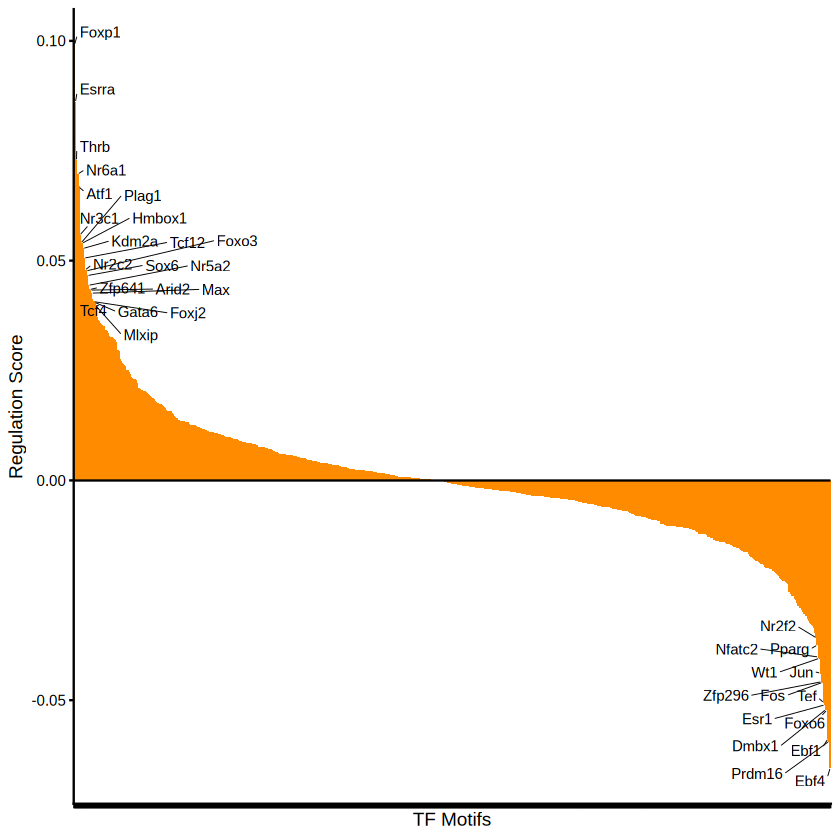

In [3]:
rank <- rankDrivers(figR.d, rankBy = "meanScore")
rank

In [3]:
subsc.list <- readRDS("data/subsc.list.Rds")

An object of class Seurat 
218744 features across 4958 samples within 2 assays 
Active assay: RNA (26111 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 1 other assay present: ATAC
 7 dimensional reductions calculated: pca, harmony, rlsi, lsi, umap, RNA.umap, ATAC.umap

Splitting ‘counts’, ‘data’ layers. Not splitting ‘scale.data’. If you would like to split other layers, set in `layers` argument.

Normalizing layer: counts.NP1

Normalizing layer: counts.NP2

Normalizing layer: counts.NP3

Normalizing layer: counts.EP1

Normalizing layer: counts.EP2

Normalizing layer: counts.EP3

Normalizing layer: counts.MP1

Normalizing layer: counts.MP2

Normalizing layer: counts.MP3

Normalizing layer: counts.LP1

Normalizing layer: counts.LP2

Normalizing layer: counts.LP3

Normalizing layer: counts.PP1

Normalizing layer: counts.PP2

Normalizing layer: counts.PP3

Finding variable features for layer counts.NP1

Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -2.4847”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.49648”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition nu

Matrix object input detectedCentering counts for cells sequentially in groups of size  1000  ..

Computing centered counts for cells:  1  to  1000 ..
Computing centered counts per cell using mean reads in features ..

Computing centered counts for cells:  1001  to  2000 ..
Computing centered counts per cell using mean reads in features ..

Computing centered counts for cells:  2001  to  3000 ..
Computing centered counts per cell using mean reads in features ..

Computing centered counts for cells:  3001  to  4000 ..
Computing centered counts per cell using mean reads in features ..

Computing centered counts for cells:  4001  to  4958 ..
Computing centered counts per cell using mean reads in features ..

Merging results..
Done!


Peaks with 0 accessibility across cells exist ..

Removing these peaks prior to running correlations ..

Important: peak indices in returned gene-peak maps are relative to original input SE

Genes with 0 expression across cells exist ..

Removing these genes prior to running correlations ..



Number of peaks in ATAC data: 191684 
Number of genes in RNA data: 20757 

Num genes overlapping TSS annotation and RNA matrix being considered:  17717 

Taking peak summits from peak windows ..
Finding overlapping peak-gene pairs ..


...

Getting peak x motif matches ..


Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM, chr1_GL455991_alt, chr1_GL455992_alt, chr1_GL455993_alt, chr1_GL456005_alt, chr1_JH584315_alt, chr1_JH584320_alt, chr1_JH584321_alt, chr1_JH584322_alt, chr2_GL456024_alt, chr3_GL456006_alt, chr3_GL456007_alt, chr3_GL456008_alt, chr3_GL456042_alt, chr3_GL456044_alt, chr3_GL456045_alt, chr3_GL456048_alt, chr3_GL456049_alt, chr3_JH584323_alt, chr4_GL455994_alt, chr4_GL456009_alt, chr4_GL456010_alt, chr4_GL456053_alt, chr4_GL456064_alt, chr4_GL456075_alt, chr4_GL456076_alt, chr4_GL456077_alt, chr4_JH584268_alt, chr4_JH584269_alt, chr4_JH584324_alt, chr4_JH584325_alt, chr4_JH584326_alt, chr5_GL455995_alt, chr5_GL456011_alt, chr6_GL456012_alt, chr6_GL456025_alt, chr6_GL456026_alt, chr6_GL456054_alt, chr6_GL456065_alt, chr6_JH584264_alt, chr7_GL455989_alt, chr7_GL456013_alt, chr7_GL456014_alt, chr8_GL455996_alt, chr8_GL455997_alt, chr10_GL456015_alt, chr

Determining background peaks ..
Using  50  iterations ..

Testing  655  TFs
Testing  118  DORCs


Running FigR using 30 cores ..




  |======================================================================| 100%Finished!
Merging results ..


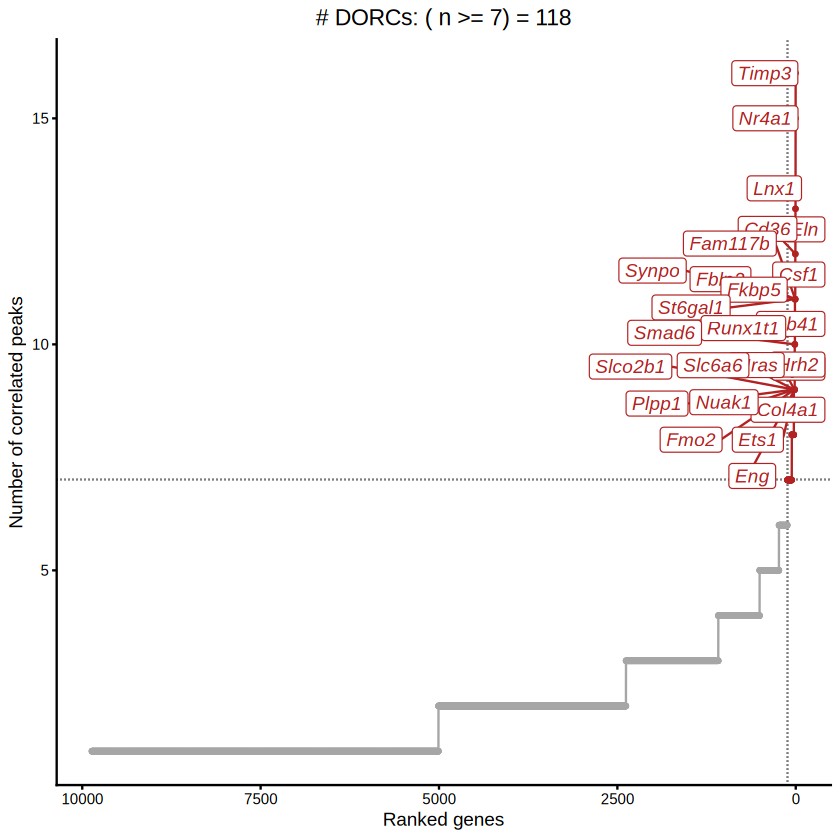

In [4]:
library(GenomeInfoDb)
EC <- subsc.list[[3]]
EC[["ATAC"]] <- readRDS("data/mHeart_ATAC.Rds")[,colnames(EC)][['ATAC']]
sub_obj <- subset(EC,subtype %in% c("EC-1","EC-2"))
DefaultAssay(sub_obj) <- "RNA"
sub_obj
set.seed(4180)
sub_obj[['RNA']] <- split(sub_obj[['RNA']],f=sub_obj$orig.ident)
sub_obj <- sub_obj %>%
 NormalizeData() %>%
 FindVariableFeatures() %>%
 ScaleData(vars.to.regress = c("percent.mt", "percent.rb", "percent.hsp"))%>%
 RunPCA()
sub_obj <- IntegrateLayers(
 object = sub_obj, method = HarmonyIntegration,
 orig.reduction = "pca", new.reduction = "harmony",
 verbose = FALSE
)
sub_obj[['RNA']] <- JoinLayers(sub_obj[['RNA']])
ATAC.se <- SummarizedExperiment(
 assays = SimpleList(counts = sub_obj@assays$ATAC$counts),
 rowRanges = sub_obj@assays$ATAC@ranges,
 colData = sub_obj@meta.data
)
rnaMat <- GetAssayData(subset(sub_obj), assay = "RNA", layer = "data")
cisCor <- runGenePeakcorr(
 ATAC.se = ATAC.se,
 RNAmat = rnaMat,
 genome = "mm10", # Also supports hg19 and hg38
 nCores = 30,
 p.cut = NULL
)
# Filter peak-gene correlations by p-value
cisCor.filt <- cisCor %>% filter(pvalZ <= 0.05)
# Determine DORC genes
dorcGenes <- cisCor.filt %>% dorcJPlot(
 cutoff = 7, # Default
 returnGeneList = TRUE
)
# Get DORC scores
dorcMat <- getDORCScores(ATAC.se, dorcTab = cisCor.filt, geneList = dorcGenes, nCores = 30)
# This takes longer since it's all genes
cellkNN <- FNN::get.knn(sub_obj@reductions$harmony@cell.embeddings, k = 30)$nn.index
rownames(cellkNN) <- colnames(rnaMat)
dorcMat.s <- smoothScoresNN(NNmat = cellkNN[, 1:30], mat = dorcMat, nCores = 30)
# Smooth RNA using cell KNNs
# This takes longer since it's all genes
RNAmat.s <- smoothScoresNN(NNmat = cellkNN[, 1:30], mat = rnaMat, nCores = 30)
# Run FigR
figR.d <- runFigRGRN(ATAC.se = ATAC.se, # Must be the same input as used in runGenePeakcorr()
 dorcTab = cisCor.filt, # Filtered peak-gene associations
 genome = "mm10",
 dorcMat = dorcMat.s,
 rnaMat = RNAmat.s,
 nCores = 30)
saveRDS(figR.d, "data/EC2_figR.rds")

Splitting ‘counts’, ‘data’ layers. Not splitting ‘scale.data’. If you would like to split other layers, set in `layers` argument.

Normalizing layer: counts.NP1

Normalizing layer: counts.NP2

Normalizing layer: counts.NP3

Normalizing layer: counts.EP1

Normalizing layer: counts.EP2

Normalizing layer: counts.EP3

Normalizing layer: counts.MP1

Normalizing layer: counts.MP2

Normalizing layer: counts.MP3

Normalizing layer: counts.LP1

Normalizing layer: counts.LP2

Normalizing layer: counts.LP3

Normalizing layer: counts.PP1

Normalizing layer: counts.PP2

Normalizing layer: counts.PP3

Finding variable features for layer counts.NP1

Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -2.4401”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.49891”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition nu

Matrix object input detectedCentering counts for cells sequentially in groups of size  1000  ..

Computing centered counts for cells:  1  to  1000 ..
Computing centered counts per cell using mean reads in features ..

Computing centered counts for cells:  1001  to  2000 ..
Computing centered counts per cell using mean reads in features ..

Computing centered counts for cells:  2001  to  3000 ..
Computing centered counts per cell using mean reads in features ..

Computing centered counts for cells:  3001  to  4000 ..
Computing centered counts per cell using mean reads in features ..

Computing centered counts for cells:  4001  to  4549 ..
Computing centered counts per cell using mean reads in features ..

Merging results..
Done!


Peaks with 0 accessibility across cells exist ..

Removing these peaks prior to running correlations ..

Important: peak indices in returned gene-peak maps are relative to original input SE

Genes with 0 expression across cells exist ..

Removing these genes prior to running correlations ..



Number of peaks in ATAC data: 192515 
Number of genes in RNA data: 21744 

Num genes overlapping TSS annotation and RNA matrix being considered:  18352 

Taking peak summits from peak windows ..
Finding overlapping peak-gene pairs ..


Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM, chr1_GL456210_random, chr1_GL456211_random, chr1_GL456212_random, chr1_GL456221_random, chr4_GL456216_random, chr4_GL456350_random, chr4_JH584292_random, chr4_JH584293_random, chr4_JH584294_random, chr4_JH584295_random, chr5_GL456354_random, chr5_JH584296_random, chr5_JH584297_random, chr5_JH584298_random, chr5_JH584299_random, chr7_GL456219_random, chrX_GL456233_random, chrY_JH584300_random, chrY_JH584301_random, chrY_JH584302_random, chrUn_GL456366, chrUn_GL456372, chrUn_JH584304
  - in 'y': GL456211.1, GL456216.1, GL456233.1, JH584292.1, JH584295.1, JH584304.1
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”


...

Getting peak x motif matches ..


Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM, chr1_GL455991_alt, chr1_GL455992_alt, chr1_GL455993_alt, chr1_GL456005_alt, chr1_JH584315_alt, chr1_JH584320_alt, chr1_JH584321_alt, chr1_JH584322_alt, chr2_GL456024_alt, chr3_GL456006_alt, chr3_GL456007_alt, chr3_GL456008_alt, chr3_GL456042_alt, chr3_GL456044_alt, chr3_GL456045_alt, chr3_GL456048_alt, chr3_GL456049_alt, chr3_JH584323_alt, chr4_GL455994_alt, chr4_GL456009_alt, chr4_GL456010_alt, chr4_GL456053_alt, chr4_GL456064_alt, chr4_GL456075_alt, chr4_GL456076_alt, chr4_GL456077_alt, chr4_JH584268_alt, chr4_JH584269_alt, chr4_JH584324_alt, chr4_JH584325_alt, chr4_JH584326_alt, chr5_GL455995_alt, chr5_GL456011_alt, chr6_GL456012_alt, chr6_GL456025_alt, chr6_GL456026_alt, chr6_GL456054_alt, chr6_GL456065_alt, chr6_JH584264_alt, chr7_GL455989_alt, chr7_GL456013_alt, chr7_GL456014_alt, chr8_GL455996_alt, chr8_GL455997_alt, chr10_GL456015_alt, chr

Determining background peaks ..
Using  50  iterations ..

Testing  675  TFs
Testing  87  DORCs


Running FigR using 30 cores ..




  |======================================================================| 100%Finished!
Merging results ..


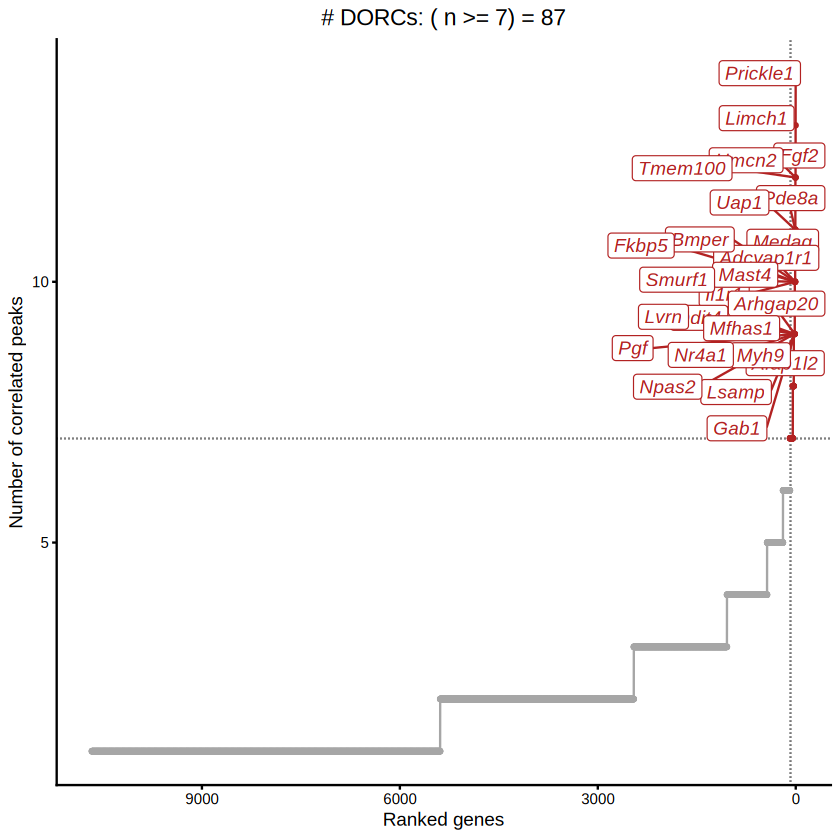

In [6]:
library(GenomeInfoDb)
FB <- subsc.list[[2]]
FB[["ATAC"]] <- readRDS("data/mHeart_ATAC.Rds")[,colnames(FB)][['ATAC']]
sub_obj <- subset(FB,subtype %in% "FB-2")
DefaultAssay(sub_obj) <- "RNA"
set.seed(4180)
sub_obj[['RNA']] <- split(sub_obj[['RNA']],f=sub_obj$orig.ident)
sub_obj <- sub_obj %>%
 NormalizeData() %>%
 FindVariableFeatures() %>%
 ScaleData(vars.to.regress = c("percent.mt", "percent.rb", "percent.hsp"))%>%
 RunPCA()
sub_obj <- IntegrateLayers(
 object = sub_obj, method = HarmonyIntegration,
 orig.reduction = "pca", new.reduction = "harmony",
 verbose = FALSE
)
sub_obj[['RNA']] <- JoinLayers(sub_obj[['RNA']])
ATAC.se <- SummarizedExperiment(
 assays = SimpleList(counts = sub_obj@assays$ATAC$counts),
 rowRanges = sub_obj@assays$ATAC@ranges,
 colData = sub_obj@meta.data
)
rnaMat <- GetAssayData(subset(sub_obj), assay = "RNA", layer = "data")
cisCor <- runGenePeakcorr(
 ATAC.se = ATAC.se,
 RNAmat = rnaMat,
 genome = "mm10", # Also supports hg19 and hg38
 nCores = 30,
 p.cut = NULL
)
# Filter peak-gene correlations by p-value
cisCor.filt <- cisCor %>% filter(pvalZ <= 0.05)
# Determine DORC genes
dorcGenes <- cisCor.filt %>% dorcJPlot(
 cutoff = 7, # Default
 returnGeneList = TRUE
)
# Get DORC scores
dorcMat <- getDORCScores(ATAC.se, dorcTab = cisCor.filt, geneList = dorcGenes, nCores = 30)
# This takes longer since it's all genes
cellkNN <- FNN::get.knn(sub_obj@reductions$harmony@cell.embeddings, k = 30)$nn.index
rownames(cellkNN) <- colnames(rnaMat)
dorcMat.s <- smoothScoresNN(NNmat = cellkNN[, 1:30], mat = dorcMat, nCores = 30)
# Smooth RNA using cell KNNs
# This takes longer since it's all genes
RNAmat.s <- smoothScoresNN(NNmat = cellkNN[, 1:30], mat = rnaMat, nCores = 30)
# Run FigR
figR.d <- runFigRGRN(ATAC.se = ATAC.se, # Must be the same input as used in runGenePeakcorr()
 dorcTab = cisCor.filt, # Filtered peak-gene associations
 genome = "mm10",
 dorcMat = dorcMat.s,
 rnaMat = RNAmat.s,
 nCores = 30)
saveRDS(figR.d, "data/FB2_figR.rds")